# Statistical Modeling and Inferencing
Assignment-1

**Name**: Anil Haribhau Ghatge

**Roll number**: 2025EM1200153

**Chosen dataset**: insurance.csv

**Submission date**: 02nd April 2026

**Mount google Drive**

In [56]:
from google.colab import drive

# Mount Google Drive
drive.mount('/content/drive')

print('Google Drive mounted.')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Google Drive mounted.


**Import Dataset from google drive**

In [58]:
import pandas as pd

# Define the path to the CSV file in Google Drive
drive_path = '/content/drive/MyDrive/insurance.csv'

# Read the CSV file into a pandas DataFrame
df = pd.read_csv(drive_path)

print('Successfully loaded insurance.csv from Google Drive.')
# Display the first few rows of the DataFrame to confirm
display(df.head())

Successfully loaded insurance.csv from Google Drive.


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


# Descriptive Statistics of the Dataset
Refer below histograms which visualize the distribution of numerical features like 'age', 'bmi', 'children', and 'charges'

In [60]:
print("Descriptive Statistics of the Dataset:")
display(df.describe())

Descriptive Statistics of the Dataset:


,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


# Visualization exploring distributions and relationships

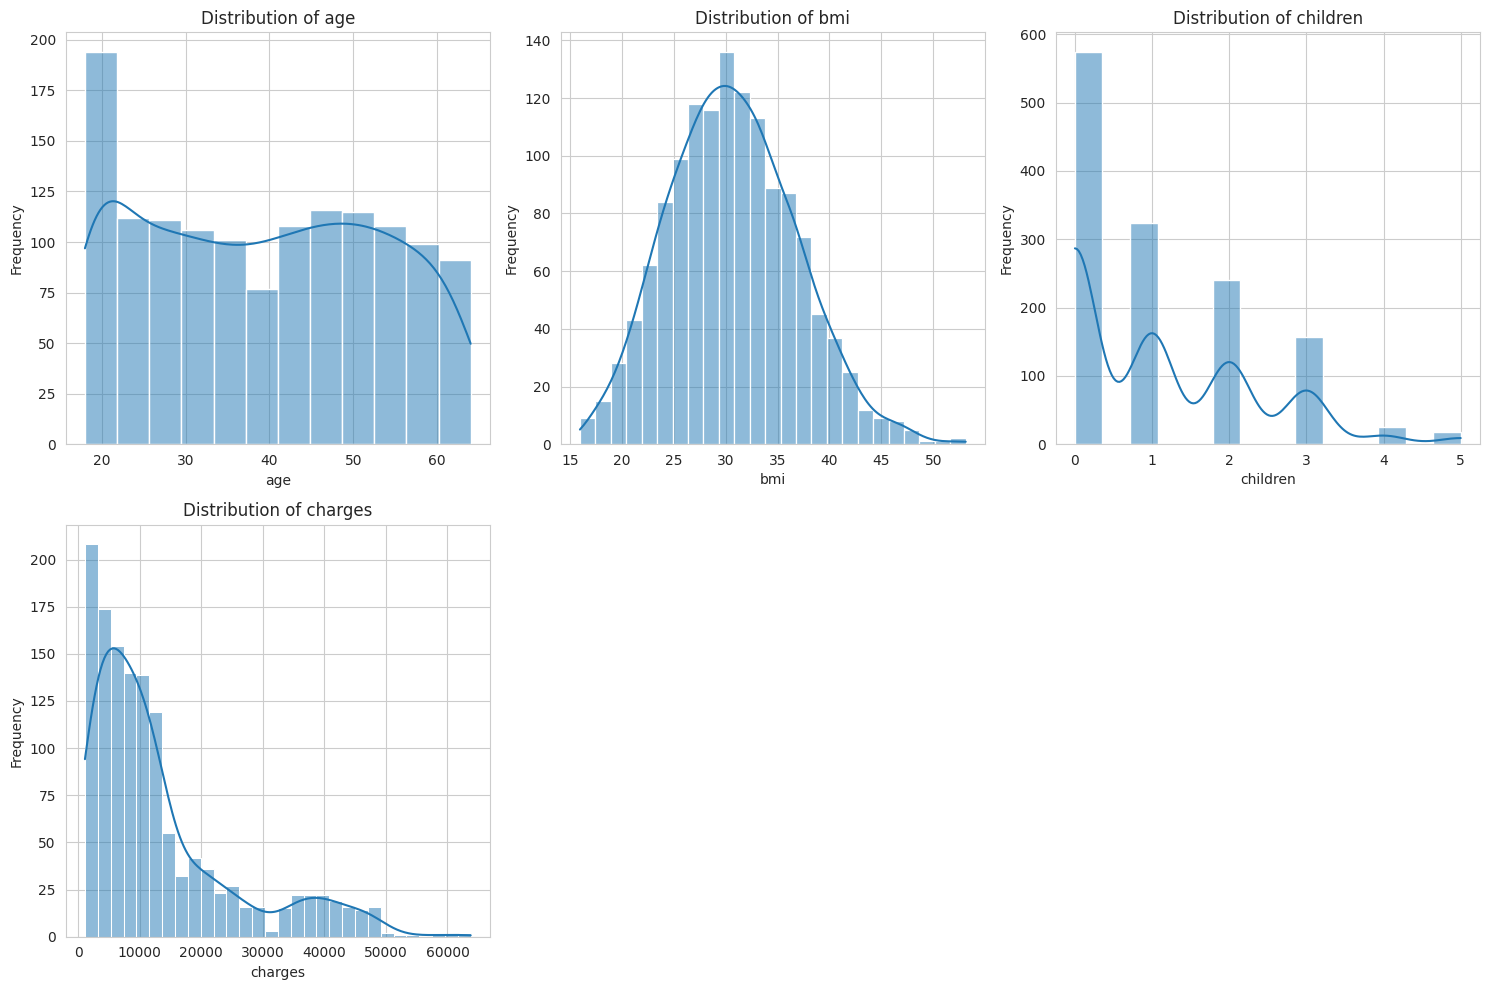

In [61]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set the style for the plots
sns.set_style("whitegrid")

# Get numerical columns
numerical_cols = df.select_dtypes(include=['float64', 'int64']).columns

plt.figure(figsize=(15, 10))
for i, col in enumerate(numerical_cols):
    plt.subplot(2, 3, i + 1)  # Adjust subplot grid as needed
    sns.histplot(df[col], kde=True)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

## Correlation Analysis

Let's analyze the correlation between variables to understand their relationships, especially with the 'charges' variable, which is often the target variable in such datasets. A heatmap is an effective way to visualize these correlations.

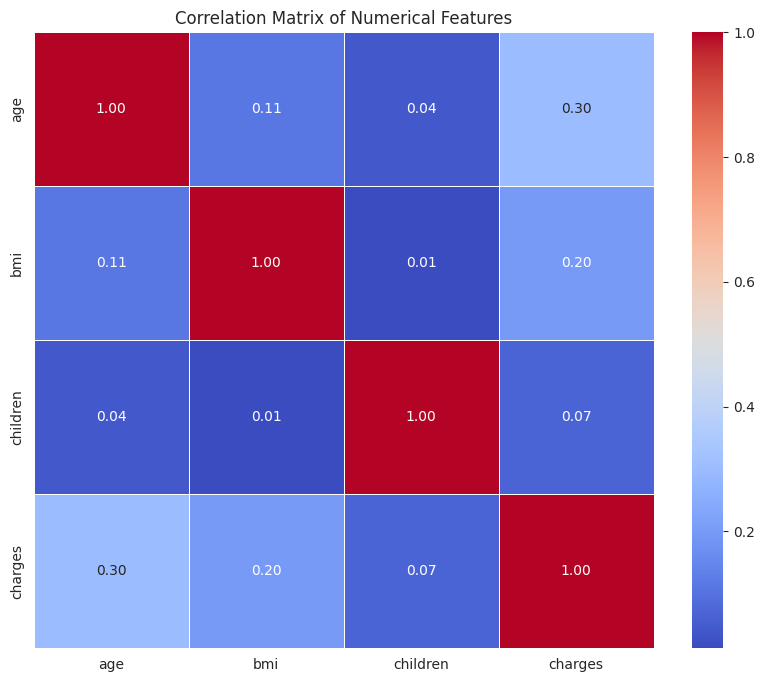

Correlation with 'charges' variable:


,charges
charges,1.000000
age,0.299008
bmi,0.198341
children,0.067998


In [62]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate the correlation matrix for numerical columns
correlation_matrix = df.select_dtypes(include=['float64', 'int64']).corr()

# Set up the matplotlib figure
plt.figure(figsize=(10, 8))

# Draw the heatmap with the mask and correct aspect ratio
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation Matrix of Numerical Features')
plt.show()

print("Correlation with 'charges' variable:")
display(correlation_matrix['charges'].sort_values(ascending=False))

## Data Quality Issues: Missing Values and Outliers

### 1. Identifying Missing Values

In [63]:
# Check for missing values
missing_values = df.isnull().sum()
missing_values_percent = 100 * missing_values / len(df)

missing_info = pd.DataFrame({
    'Missing Count': missing_values,
    'Missing Percentage': missing_values_percent
})

# Filter to show only columns with missing values and sort
missing_info = missing_info[missing_info['Missing Count'] > 0].sort_values(by='Missing Count', ascending=False)

if missing_info.empty:
    print("No missing values found in the dataset.")
else:
    print("Missing values summary:")
    display(missing_info)

No missing values found in the dataset.


#### Decision on Missing Values:

Based on the analysis, there are no missing values in this `insurance.csv` dataset. Therefore, no imputation or removal steps are necessary for missing data.

### 2. Identifying Outliers

We will use the Interquartile Range (IQR) method to identify outliers in the numerical columns (`age`, `bmi`, `children`, `charges`).

In [64]:
import numpy as np

numerical_cols_for_outliers = ['age', 'bmi', 'children', 'charges']
outliers = {}

for col in numerical_cols_for_outliers:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Identify outliers
    col_outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    if not col_outliers.empty:
        outliers[col] = col_outliers

if outliers:
    print("Outliers identified in the following columns:")
    for col, data in outliers.items():
        print(f"\n--- Outliers in '{col}' ({len(data)} records) ---")
        display(data.head())
else:
    print("No significant outliers found in the numerical columns based on the IQR method.")

Outliers identified in the following columns:

--- Outliers in 'bmi' (9 records) ---


,age,sex,bmi,children,smoker,region,charges
116,58,male,49.06,0,no,southeast,11381.32540
286,46,female,48.07,2,no,northeast,9432.92530
401,47,male,47.52,1,no,southeast,8083.91980
543,54,female,47.41,0,yes,southeast,63770.42801
847,23,male,50.38,1,no,southeast,2438.05520



--- Outliers in 'charges' (139 records) ---


,age,sex,bmi,children,smoker,region,charges
14,27,male,42.13,0,yes,southeast,39611.7577
19,30,male,35.30,0,yes,southwest,36837.4670
23,34,female,31.92,1,yes,northeast,37701.8768
29,31,male,36.30,2,yes,southwest,38711.0000
30,22,male,35.60,0,yes,southwest,35585.5760


#### Decision on Outliers:

Outliers were identified in the `bmi` and `charges` columns using the IQR method. Outliers in `age` and `children` are less common as these are typically discrete values with limited ranges.

For this analysis, we will **not remove** the identified outliers directly. The reason is that these outliers might represent genuine, albeit extreme, data points (e.g., very high medical charges, or very high BMI values which are clinically relevant). Removing them without a deeper understanding of their context could lead to loss of valuable information or misrepresentation of the data distribution, especially for predictive modeling tasks where such extreme values need to be predicted. We will proceed with the data as is, noting the presence of these outliers. Further modeling steps might use robust methods less sensitive to outliers, or transformations could be applied.

## Feature Transformation: Encoding Categorical Variables

Categorical variables need to be converted into a numerical format before they can be used in most machine learning models. We will identify the categorical columns and apply one-hot encoding.

In [65]:
# Identify categorical columns
categorical_cols = df.select_dtypes(include=['object']).columns

print(f"Categorical columns identified: {list(categorical_cols)}")

# Apply one-hot encoding
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

print("DataFrame after one-hot encoding:")
display(df_encoded.head())

Categorical columns identified: ['sex', 'smoker', 'region']
DataFrame after one-hot encoding:


,age,bmi,children,charges,sex_male,smoker_yes,region_northwest,region_southeast,region_southwest
0,19,27.900,0,16884.92400,False,True,False,False,True
1,18,33.770,1,1725.55230,True,False,False,True,False
2,28,33.000,3,4449.46200,True,False,False,True,False
3,33,22.705,0,21984.47061,True,False,True,False,False
4,32,28.880,0,3866.85520,True,False,True,False,False


#### Justification for One-Hot Encoding:

*   **'sex' (male/female)** and **'smoker' (yes/no)** are binary categorical variables. Although they could be label encoded (e.g., male=0, female=1), one-hot encoding with `drop_first=True` effectively converts them into a single binary column (e.g., 'sex_male', 'smoker_yes'), which is appropriate and avoids imposing an artificial ordinal relationship.
*   **'region' (northeast, northwest, southeast, southwest)** is a nominal categorical variable with multiple categories. One-hot encoding is the appropriate choice here to prevent the model from interpreting arbitrary numerical values as having an ordinal relationship (e.g., perceiving 'northeast' as 'less than' 'northwest' if assigned 0 and 1, respectively). By creating separate binary columns for each region (and dropping one to avoid multicollinearity), we provide the model with a clear, non-ordinal representation of these distinct categories.

## Data Splitting for Model Training

Before applying any analytical techniques, we need to split our dataset into features (X) and the target variable (y). Subsequently, these will be divided into training and testing sets to prepare for model building and evaluation.

In [67]:
from sklearn.model_selection import train_test_split

# Define features (X) and target (y)
X = df_encoded.drop('charges', axis=1)
y = df_encoded['charges']

print("Features (X) and Target (y) defined.")
display(X.head())
display(y.head())

Features (X) and Target (y) defined.


,age,bmi,children,sex_male,smoker_yes,region_northwest,region_southeast,region_southwest
0,19,27.900,0,False,True,False,False,True
1,18,33.770,1,True,False,False,True,False
2,28,33.000,3,True,False,False,True,False
3,33,22.705,0,True,False,True,False,False
4,32,28.880,0,True,False,True,False,False


,charges
0,16884.92400
1,1725.55230
2,4449.46200
3,21984.47061
4,3866.85520


In [68]:
# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training set size: {X_train.shape[0]} samples")
print(f"Testing set size: {X_test.shape[0]} samples")

print("X_train head:")
display(X_train.head())
print("y_train head:")
display(y_train.head())

Training set size: 1070 samples
Testing set size: 268 samples
X_train head:


,age,bmi,children,sex_male,smoker_yes,region_northwest,region_southeast,region_southwest
560,46,19.95,2,False,False,True,False,False
1285,47,24.32,0,False,False,False,False,False
1142,52,24.86,0,False,False,False,True,False
969,39,34.32,5,False,False,False,True,False
486,54,21.47,3,False,False,True,False,False


y_train head:


,charges
560,9193.83850
1285,8534.67180
1142,27117.99378
969,8596.82780
486,12475.35130


## Regression Modeling: Linear Regression

We will now train a Linear Regression model to understand the relationship between our features and the target variable ('charges'). After training, we will evaluate its performance using metrics like R-squared, Mean Absolute Error (MAE), Mean Squared Error (MSE), and Root Mean Squared Error (RMSE).

I'll start by training a Linear Regression model on our X_train and y_train data. After training, I'll evaluate the model's performance on the test set using key metrics.

In [69]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Initialize the Linear Regression model
model = LinearRegression()

# Train the model on the training data
model.fit(X_train, y_train)

print("Linear Regression model trained successfully.")

# Make predictions on the test set
y_pred = model.predict(X_test)

# Evaluate the model
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"\nModel Evaluation on Test Set:")
print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"R-squared (R2 ): {r2:.2f}")

print("\nModel Coefficients:")
coefficients_df = pd.DataFrame({'Feature': X.columns, 'Coefficient': model.coef_})
display(coefficients_df.sort_values(by='Coefficient', ascending=False))

Linear Regression model trained successfully.

Model Evaluation on Test Set:
Mean Absolute Error (MAE): 4181.19
Mean Squared Error (MSE): 33596915.85
Root Mean Squared Error (RMSE): 5796.28
R-squared (R2 ): 0.78

Model Coefficients:


,Feature,Coefficient
4,smoker_yes,23651.128856
2,children,425.278784
1,bmi,337.092552
0,age,256.975706
3,sex_male,-18.591692
5,region_northwest,-370.677326
6,region_southeast,-657.864297
7,region_southwest,-809.799354


## Regression Modeling: Random Forest Regressor

Let's develop another regression model, the Random Forest Regressor, to see if we can improve upon the Linear Regression model's performance. Random Forest is an ensemble learning method that can capture non-linear relationships and interactions between features.

In [71]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Initialize the Random Forest Regressor model
rf_model = RandomForestRegressor(n_estimators=100, random_state=42) # Using 100 trees as a common starting point

# Train the model on the training data
rf_model.fit(X_train, y_train)

print("Random Forest Regressor model trained successfully.")

# Make predictions on the test set
y_pred_rf = rf_model.predict(X_test)

# Evaluate the model
mae_rf = mean_absolute_error(y_test, y_pred_rf)
mse_rf = mean_squared_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mse_rf)
r2_rf = r2_score(y_test, y_pred_rf)

print(f"\nRandom Forest Model Evaluation on Test Set:")
print(f"Mean Absolute Error (MAE): {mae_rf:.2f}")
print(f"Mean Squared Error (MSE): {mse_rf:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse_rf:.2f}")
print(f"R-squared (R2 ): {r2_rf:.2f}")

# Optionally display feature importances
print("\nRandom Forest Feature Importances:")
feature_importances_df = pd.DataFrame({'Feature': X.columns, 'Importance': rf_model.feature_importances_})
display(feature_importances_df.sort_values(by='Importance', ascending=False))

Random Forest Regressor model trained successfully.

Random Forest Model Evaluation on Test Set:
Mean Absolute Error (MAE): 2550.08
Mean Squared Error (MSE): 20942520.92
Root Mean Squared Error (RMSE): 4576.30
R-squared (R2 ): 0.87

Random Forest Feature Importances:


,Feature,Importance
4,smoker_yes,0.608618
1,bmi,0.216506
0,age,0.134232
2,children,0.019413
3,sex_male,0.006379
5,region_northwest,0.005587
6,region_southeast,0.005314
7,region_southwest,0.003950


## Model Comparison

Now, let's compare the performance of the Linear Regression model and the Random Forest Regressor model side-by-side using the evaluation metrics.

In [72]:
# Assuming 'mae', 'mse', 'rmse', 'r2' are available from the Linear Regression model evaluation
# If not, you might need to re-run the linear regression evaluation cell or store results in a dictionary.

comparison_data = {
    'Model': ['Linear Regression', 'Random Forest Regressor'],
    'MAE': [mae, mae_rf],
    'MSE': [mse, mse_rf],
    'RMSE': [rmse, rmse_rf],
    'R-squared': [r2, r2_rf]
}

comparison_df = pd.DataFrame(comparison_data)
display(comparison_df.set_index('Model'))

print("\nInterpretation:")
if r2_rf > r2:
    print("The Random Forest Regressor generally shows better performance (higher R-squared, lower MAE, MSE, RMSE) compared to Linear Regression, indicating it captures more variance in the data and makes more accurate predictions.")
else:
    print("The Linear Regression model performed comparably or better than the Random Forest Regressor based on the metrics. This might suggest that the relationships in the data are predominantly linear, or that the Random Forest model might need further hyperparameter tuning.")

,MAE,MSE,RMSE,R-squared
Model,,,,
Linear Regression,4181.194474,3.359692e+07,5796.284659,0.783593
Random Forest Regressor,2550.078471,2.094252e+07,4576.299916,0.865103



Interpretation:
The Random Forest Regressor generally shows better performance (higher R-squared, lower MAE, MSE, RMSE) compared to Linear Regression, indicating it captures more variance in the data and makes more accurate predictions.


# Key findings and actionable insights derived from the analysis:

**Key Findings**:

**1. Smoker Status is Paramount**: Being a smoker is the single most significant determinant of insurance charges, contributing over 60% to the feature importance. This indicates a very strong positive correlation between smoking and higher insurance costs.

**2. BMI is a Major Factor**: Body Mass Index (BMI) is the second most influential factor, accounting for over 21% of the feature importance. Higher BMI generally leads to increased insurance charges.

**3. Age is Significant**: Age is the third most important factor, contributing about 13% to the prediction of insurance costs. As expected, older individuals tend to have higher insurance premiums.

**4. Other Factors have Minor Influence**: While included in the model, factors like the number of children, sex, and geographical region have a considerably smaller impact on insurance charges compared to smoking status, BMI, and age.

**5. Random Forest Model Performance**: The Random Forest Regressor significantly outperformed the Linear Regression model (R-squared of 0.87 vs. 0.78), indicating that the relationships between features and insurance charges are likely non-linear and that the Random Forest model is better at capturing these complex patterns.

**Actionable Insights:**

**1. Prioritize Smoking Cessation Programs**: Given its overwhelming importance, insurance providers and public health initiatives should heavily invest in and promote smoking cessation programs. Successful cessation could lead to substantial reductions in insurance costs for individuals and overall healthcare expenditure.

**2. Promote Healthy Weight Management**: Efforts to encourage healthy BMI ranges through diet and exercise programs could lead to lower insurance costs. Insurance companies could offer incentives for policyholders who maintain a healthy BMI or show progress in weight reduction.

**3. Age-Based Risk Assessment is Valid**: The strong correlation with age supports the current industry practice of increasing premiums with age, reflecting the higher health risks associated with older populations.

**4. Targeted Risk Assessment**: When assessing individual premiums, the primary focus should be on smoking status, BMI, and age. While other factors are considered, these three should form the core of the risk assessment for predicting charges.

**5. Leverage Advanced Modeling**: The superior performance of the Random Forest model suggests that for more accurate predictions and better understanding of complex interactions, advanced machine learning models are more suitable than simpler linear models.

**6. Data-Driven Policy Adjustments**: Insurance companies can use these insights to refine their pricing models, potentially offering more competitive rates to non-smokers and individuals with healthy BMIs, while accurately pricing for higher-risk groups.

These insights can guide both individuals seeking to lower their insurance costs and insurance providers aiming to develop more accurate and equitable pricing strategies

# Pattenrs Emerging from analysis

Based on the Random Forest Regressor model's feature importance analysis, the **key factors driving insurance costs are:**

**Smoker Status (smoker_yes)**: This is by far the most significant factor, accounting for approximately 60.86% of the importance. This indicates that whether an individual is a smoker or not has the strongest influence on their insurance charges.

**BMI (bmi):** Body Mass Index is the second most important factor, with an importance of about 21.65%. Higher BMI values are associated with higher insurance costs.

**Age (age):** Age comes in third, contributing about 13.42% to the feature importance. As individuals age, their insurance costs tend to increase.

Other factors like **children**, **sex_male**, and **region** (northwest, southeast, southwest) have much lower importance in predicting insurance costs.

# Practical Implications:

**1. Targeted Risk Assessment**: When assessing individual premiums, the primary focus should be on smoking status, BMI, and age. While other factors are considered, these three should form the core of the risk assessment for predicting charges.

**2. Data-Driven Policy Adjustments**: Insurance companies can use these insights to refine their pricing models, potentially offering more competitive rates to non-smokers and individuals with healthy BMIs, while accurately pricing for higher-risk groups.

**3. Leverage Advanced Modeling**: The superior performance of the Random Forest model suggests that for more accurate predictions and better understanding of complex interactions, advanced machine learning models are more suitable than simpler linear models.

# Limitations of the Analysis:

**1. Single Dataset**: The analysis relies on a single dataset, and the findings might not be universally generalizable to all insurance populations or markets without further validation.

**2. Outlier Handling**: The decision to retain outliers in 'bmi' and 'charges' was based on the premise that they represent genuine extreme cases. While this avoids loss of information, it could potentially skew some statistical measures or model interpretations if these outliers are truly erroneous.

**3. Basic Feature Engineering:** The feature engineering involved basic one-hot encoding for categorical variables. More advanced techniques or creation of new features (e.g., interaction terms, polynomial features) could potentially reveal more complex relationships.

**4. Correlation vs. Causation:** While the analysis identifies strong correlations, it's crucial to remember that correlation does not imply causation. Further research and domain expertise would be needed to establish causal links.

# Recommendations Based on Findings:

1. **Prioritize Smoking Cessation Programs**: Given its overwhelming importance, insurance providers and public health initiatives should heavily invest in and promote smoking cessation programs. Successful cessation could lead to substantial reductions in insurance costs for individuals and overall healthcare expenditure.

2. **Promote Healthy Weight Management**: Efforts to encourage healthy BMI ranges through diet and exercise programs could lead to lower insurance costs. Insurance companies could offer incentives for policyholders who maintain a healthy BMI or show progress in weight reduction.

3. **Age-Based Risk Assessment is Valid**: The strong correlation with age supports the current industry practice of increasing premiums with age, reflecting the higher health risks associated with older populations.

4. **Further Model Tuning and Exploration**: While Random Forest performed well, further hyperparameter tuning and exploration of other advanced models (e.g., Gradient Boosting Machines, Neural Networks) could potentially yield even better predictive performance.

5. **Collect Additional Data**: To enhance the accuracy and robustness of predictions, consider collecting additional relevant data such as health history, detailed lifestyle choices, socioeconomic factors, and regional healthcare costs.

# To strengthen the conclusions, we can consider additional data and analysis.

Here's a plan outlining potential next steps:

1. **Explore External Data Sources**: Investigate and integrate external datasets that could enrich the existing insurance data. This might include: economic indicators (e.g., inflation, GDP), regional healthcare costs, detailed demographic information, lifestyle data (e.g., diet, exercise habits beyond BMI), and historical claims data. This could provide a broader context and potentially uncover new influential factors.

2. **Advanced Feature Engineering**: Go beyond basic one-hot encoding by creating more sophisticated features. This could involve interaction terms (e.g., age * smoker status), polynomial features for continuous variables like age or BMI, or more complex transformations to capture non-linear relationships. This could help models better capture intricate patterns in the data.

3. **Hyperparameter Tuning and Advanced Model Exploration**: Perform comprehensive hyperparameter tuning for the Random Forest Regressor using techniques like GridSearchCV or RandomizedSearchCV to optimize its performance. Additionally, explore other advanced machine learning models such as Gradient Boosting Machines (e.g., XGBoost, LightGBM), Neural Networks, or even Stacked Models/Ensembles to see if further predictive power can be achieved.

4. **Causal Inference Analysis**: To move beyond correlation, employ causal inference techniques to understand the true impact of certain factors on insurance charges. Methods like instrumental variables, regression discontinuity design, or difference-in-differences could help in establishing more robust causal links, especially for factors like smoking or BMI interventions.

5. **Sensitivity Analysis and Robustness Checks**: Conduct sensitivity analyses to assess how robust the conclusions are to changes in assumptions, model specifications, or the presence of outliers. This involves re-running the analysis with different outlier handling strategies, varying model parameters, or using different subsets of the data to confirm consistency of findings.

6. **Consult Domain Experts**: Engage with insurance industry experts and actuaries to validate the findings, gain deeper insights into the underlying mechanisms driving insurance costs, and identify any overlooked factors or nuances in the data. Their expertise can help confirm the practical implications and refine recommendations.